In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

**Task 1**. Load the dataset 'ab_test_data.csv' into a pandas DataFrame. Explore the dataset to understand its structure, including the number of rows and columns, data types of each column, and any missing values. Provide a summary of the dataset.

In [2]:
df = pd.read_csv('datasets/ab_test_data.csv')
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(f'Dataset has {df.shape[0]} rows and {df.shape[1]} columns.')
df.head()

Dataset has 19998 rows and 4 columns.


,user_id,timestamp,test_group,conversion
0,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 04:40:55.848109,a,0
1,e6a6e960-d3f3-4074-a516-ba1e609b211e,2023-07-06 00:26:45.486187,b,0
2,4d3fbfa5-6847-410a-bac2-477f01d5f400,2023-07-10 20:24:33.639464,b,0
3,361457d9-a044-48f7-981c-d67dc3861679,2023-07-20 07:04:49.957013,b,0
4,285cd63d-7d03-427f-a062-1fa2dd2e77d6,2023-07-19 23:27:50.116680,b,0


In [3]:
df.describe(include='all')

,user_id,timestamp,test_group,conversion
count,19998,19998,19998,19998.000000
unique,19998,19998,2,NaN
top,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 04:40:55.848109,a,NaN
freq,1,1,10013,NaN
mean,NaN,NaN,NaN,0.075008
std,NaN,NaN,NaN,0.263410
min,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,0.000000


In [4]:
df.isnull().sum()

user_id       0
timestamp     0
test_group    0
conversion    0
dtype: int64

In [5]:
df.info()
print(f'Conversion values: {df["conversion"].value_counts().to_dict()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     19998 non-null  object
 1   timestamp   19998 non-null  object
 2   test_group  19998 non-null  object
 3   conversion  19998 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 625.1+ KB
Conversion values: {0: 18498, 1: 1500}


In [6]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.head()

,user_id,timestamp,test_group,conversion
0,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 04:40:55.848109,a,0
1,e6a6e960-d3f3-4074-a516-ba1e609b211e,2023-07-06 00:26:45.486187,b,0
2,4d3fbfa5-6847-410a-bac2-477f01d5f400,2023-07-10 20:24:33.639464,b,0
3,361457d9-a044-48f7-981c-d67dc3861679,2023-07-20 07:04:49.957013,b,0
4,285cd63d-7d03-427f-a062-1fa2dd2e77d6,2023-07-19 23:27:50.116680,b,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     19998 non-null  object        
 1   timestamp   19998 non-null  datetime64[ns]
 2   test_group  19998 non-null  object        
 3   conversion  19998 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 625.1+ KB


**Task 2** Number of users in each test group (A and B).

In [8]:
groups = df['test_group'].value_counts().reset_index().rename(columns={'count': 'users_count'})
groups.head()

,test_group,users_count
0,a,10013
1,b,9985


**Task 3** Number of conversions in each test group.

In [9]:
groups['conversion_count'] = df[df['conversion'] == True]['test_group'].value_counts().reset_index().rename(columns={'count': 'conversions_count'}).loc[:, 'conversions_count']
groups.head()

,test_group,users_count,conversion_count
0,a,10013,889
1,b,9985,611


**Task 4** Conversion rate for each test group.

In [10]:
groups['conversion_rate'] = df.groupby('test_group')['conversion'].mean().round(2).reset_index().rename(columns={'conversion': 'conversion_rate'}).loc[:, ['conversion_rate']]
groups

,test_group,users_count,conversion_count,conversion_rate
0,a,10013,889,0.06
1,b,9985,611,0.09


In [11]:
rconversion_rate = abs((groups.iloc[0, 3] - groups.iloc[1, 3]) / groups.iloc[1, 3])

print(f'Relative conversion rate: {rconversion_rate:.2%}')

Relative conversion rate: 33.33%


**Task 5** The day of start, end, and duration of the A/B test.

In [12]:
print(f'Start day: {df["timestamp"].min().date()}')
print(f'End day: {df["timestamp"].max().date()}')
print(f'Duration: {(df["timestamp"].max() - df["timestamp"].min()).days}')

Start day: 2023-07-03
End day: 2023-07-25
Duration: 21


In [13]:
df_a = df[df['test_group'] == 'a']
df_b = df[df['test_group'] == 'b']
print(f'A/B test statistics:')
df.groupby("test_group").describe().loc[:, ['conversion']]

A/B test statistics:


conversion                                             
                count      mean  min  25%  50%  75%  max       std
test_group                                                        
a             10013.0  0.061021  0.0  0.0  0.0  0.0  1.0  0.239380
b              9985.0  0.089034  0.0  0.0  0.0  0.0  1.0  0.284806

**Task 6** T-test for A/B test results.

In [14]:
ttest_result = stats.ttest_ind(df_a['conversion'], df_b['conversion'], equal_var=False, alternative='less')

alpha = 0.05

print(f'T-statistic: {ttest_result.statistic:.2f}')
print(f'p-value: {ttest_result.pvalue:.2f}')

T-statistic: -7.53
p-value: 0.00


**Chi-test** Chi-squared test for A/B test results.

In [25]:
cross = pd.crosstab(df['test_group'], df['conversion'])

chichi = stats.chi2_contingency(cross)

print(f'Chi-squared statistic: {chichi[0]:.2f}')
print(f'p-value: {chichi[1]:.15f}')

Chi-squared statistic: 56.14
p-value: 0.000000000000067
-335


**Task 7** Visualization of A/B test results.

C:\Users\morov\AppData\Local\Temp\ipykernel_3936\397884353.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=df, y='conversion', x='test_group', errorbar='ci', ci=95)


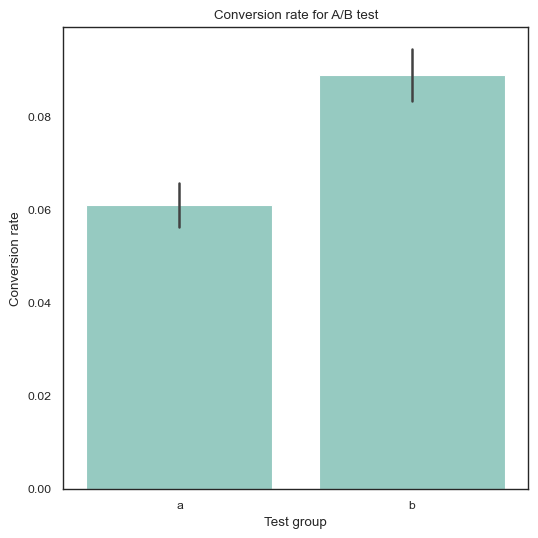

In [18]:
plt.figure(figsize=(6, 6))
sns.set_style('white')
sns.set_context('paper')
sns.barplot(data=df, y='conversion', x='test_group', errorbar='ci', ci=95)
plt.title('Conversion rate for A/B test')
plt.ylabel('Conversion rate')
plt.xlabel('Test group')
plt.savefig('plots/ab_test_conversion_rate.png', bbox_inches='tight', dpi=300)
plt.show()

,timestamp,test_group,conversion
0,2023-07-03,a,0.050971
1,2023-07-03,b,0.087640
2,2023-07-04,a,0.065022
3,2023-07-04,b,0.081858
4,2023-07-05,a,0.064220


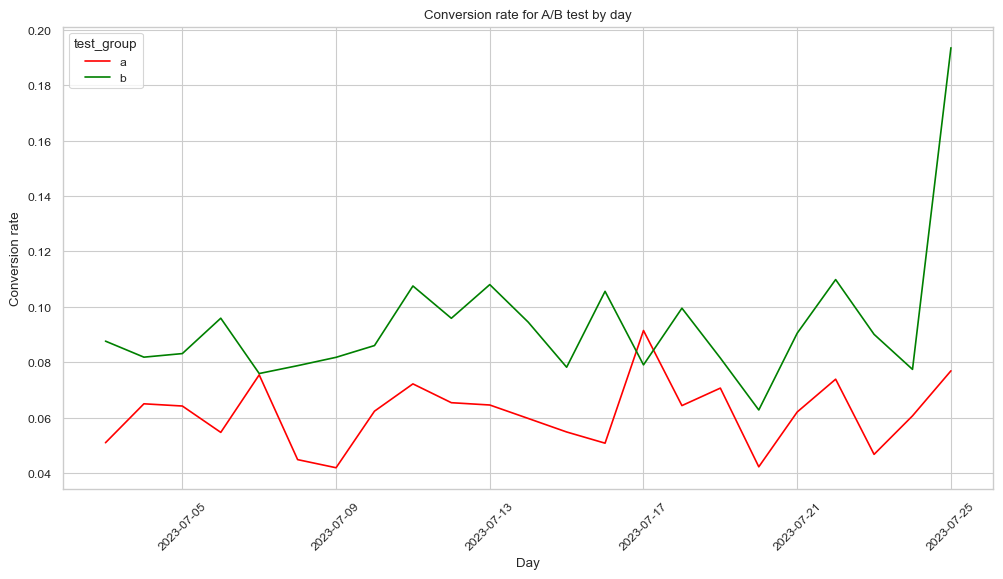

In [17]:
df_line = df.copy()
df_line['timestamp'] = df_line['timestamp'].dt.date

df_line = df_line.groupby(['timestamp', 'test_group']).agg({'conversion': 'mean'}).reset_index()

plt.figure(figsize=(12, 6))
sns.set_style('whitegrid')
sns.set_context('paper')
sns.lineplot(data=df_line, x='timestamp', y='conversion', hue='test_group', palette=['red', 'green'])
plt.title('Conversion rate for A/B test by day')
plt.ylabel('Conversion rate')
plt.xlabel('Day')
plt.xticks(rotation=45)
plt.savefig('plots/ab_test_conversion_rate_by_day.png', bbox_inches='tight', dpi=300)
df_line.head()